# 1. Setup and Data Loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('/content/Google-Playstore-Cleaned.csv', dtype={8: str, 20: str, 21: str, 22: str}, on_bad_lines='skip', engine='python')

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(df.columns.tolist())
df.head()

Rows: 50456, Columns: 26
['App Name', 'App Id', 'Category', 'Rating', 'Rating Count', 'Installs', 'Minimum Installs', 'Maximum Installs', 'Free', 'Price', 'Currency', 'Size', 'Minimum Android', 'Developer Id', 'Developer Website', 'Developer Email', 'Released', 'Last Updated', 'Content Rating', 'Privacy Policy', 'Ad Supported', 'In App Purchases', 'Editors Choice', 'Scraped Time', 'Size_MB', 'Installs_Numeric']


,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,...,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time,Size_MB,Installs_Numeric
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,0.0,...,"Feb 26, 2020",2020-02-26,Everyone,https://beniyizibyose.tk/projects/,False,False,False,2021-06-15 20:19:35,10.0,10.0
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,0.0,...,"May 21, 2020",2021-05-06,Everyone,https://dev4phones.wordpress.com/licencia-de-uso/,True,False,False,2021-06-15 20:19:35,2.9,5000.0
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,0.0,...,"Aug 9, 2019",2019-08-19,Everyone,https://www.vietnamairlines.com/vn/en/terms-an...,False,False,False,2021-06-15 20:19:35,3.7,50.0
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,0.0,...,"Sep 10, 2018",2018-10-13,Everyone,Not Available,True,False,False,2021-06-15 20:19:35,1.8,10.0
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,0.0,...,"Feb 21, 2020",2018-11-12,Everyone,http://www.horodyski.com.pl,False,False,False,2021-06-15 20:19:35,6.2,100.0


# 2. Univariate Analysis: Understanding Distributions

## 2.1 Distribution of Ratings

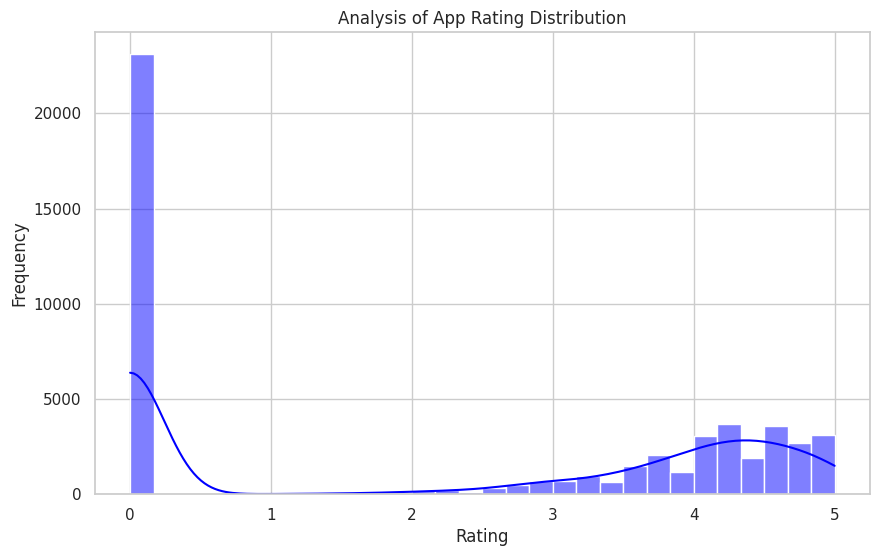

In [2]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], bins=30, kde=True, color='blue')
plt.title('Analysis of App Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

## 2.2 Boxplot for Outlier Detection (Requirement: Document outlier treatment) [cite: 213, 324]


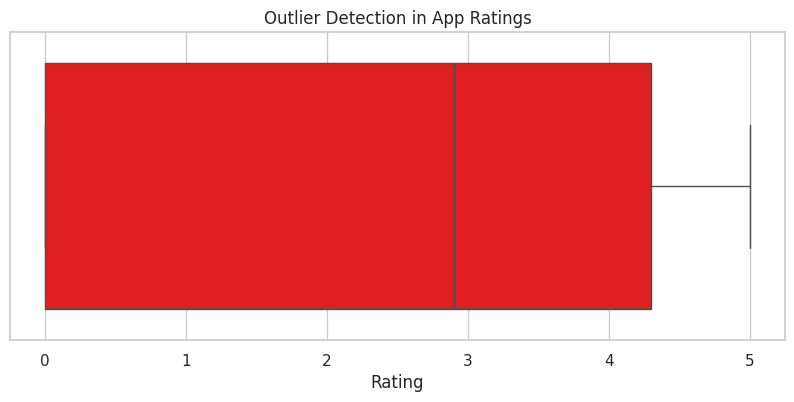

In [9]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Rating'], color='red')
plt.title('Outlier Detection in App Ratings')
plt.xlabel('Rating')
plt.show()

Lead Insight: "The Rating distribution is heavily left-skewed, indicating that the majority of surviving apps maintain high user satisfaction (4.0+), while outliers below 2.0 represent high-risk or poor-quality software.".

# 3. Comparison Analysis: Categories & Performance

## 3.1 Top 10 Categories by App Count

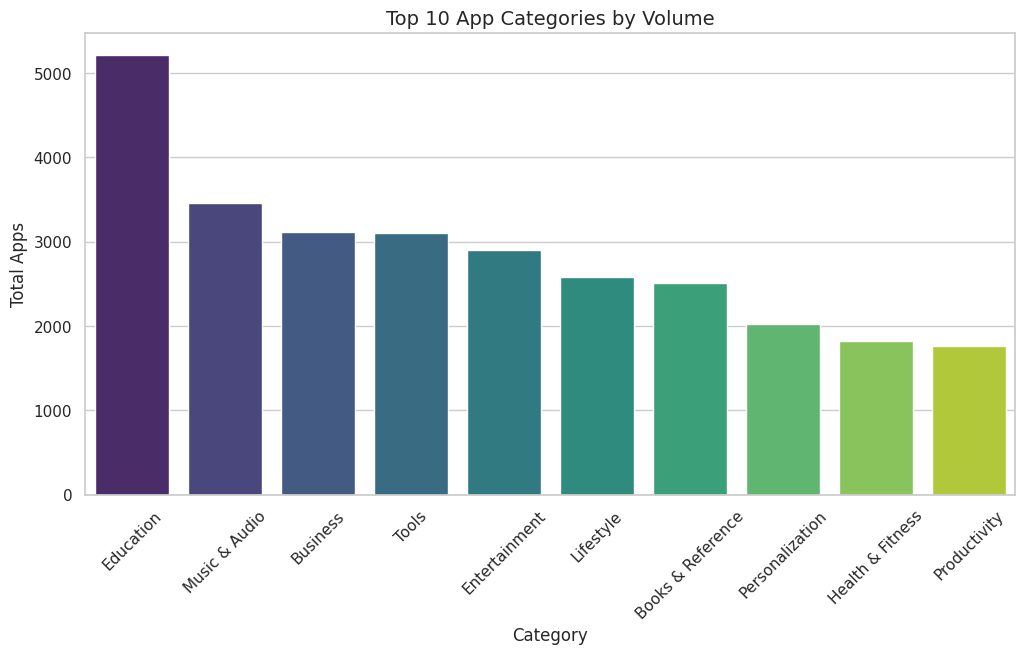

In [4]:
plt.figure(figsize=(12, 6))
top_cats = df['Category'].value_counts().head(10)

sns.barplot(x=top_cats.index, y=top_cats.values, hue=top_cats.index, palette='viridis', legend=False)

plt.title('Top 10 App Categories by Volume', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Apps')
plt.xticks(rotation=45)
plt.show()


## 3.2 Average Rating per Category (Performance Comparison)

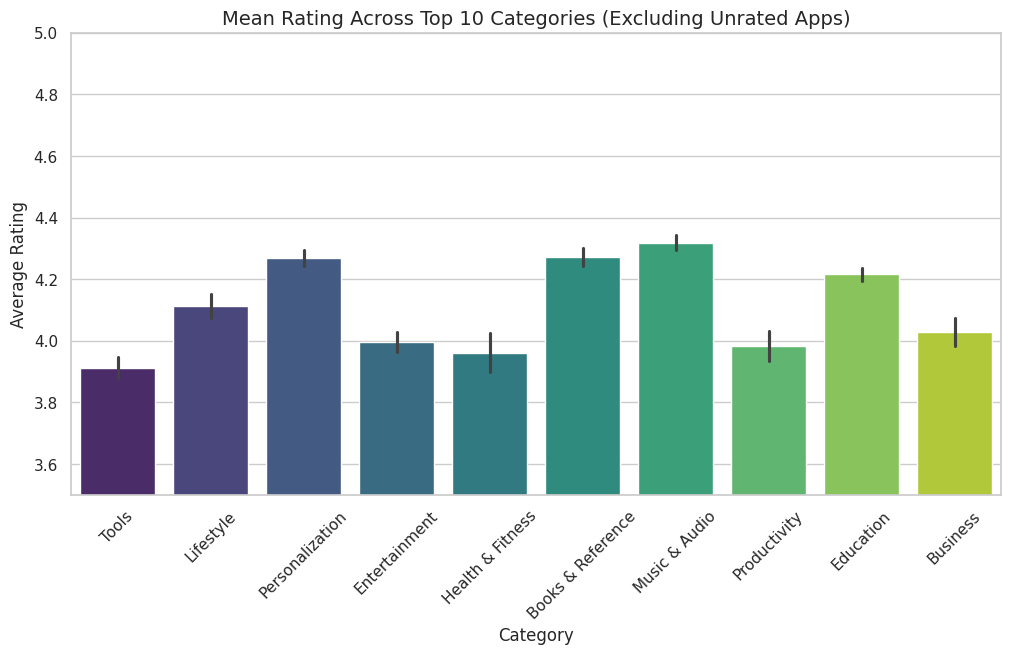

In [5]:
top_10_cats = df['Category'].value_counts().head(10).index
subset = df[(df['Category'].isin(top_10_cats)) & (df['Rating'] > 0)]

plt.figure(figsize=(12, 6))
sns.barplot(data=subset, x='Category', y='Rating', hue='Category', estimator=np.mean, palette='viridis', legend=False)

plt.title('Mean Rating Across Top 10 Categories (Excluding Unrated Apps)', fontsize=14)
plt.ylabel('Average Rating')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.ylim(3.5, 5.0)
plt.show()

#4. Correlation Analysis (Multi-variate)

## 4.1 Correlation Heatmap (Identifying variable relationships)

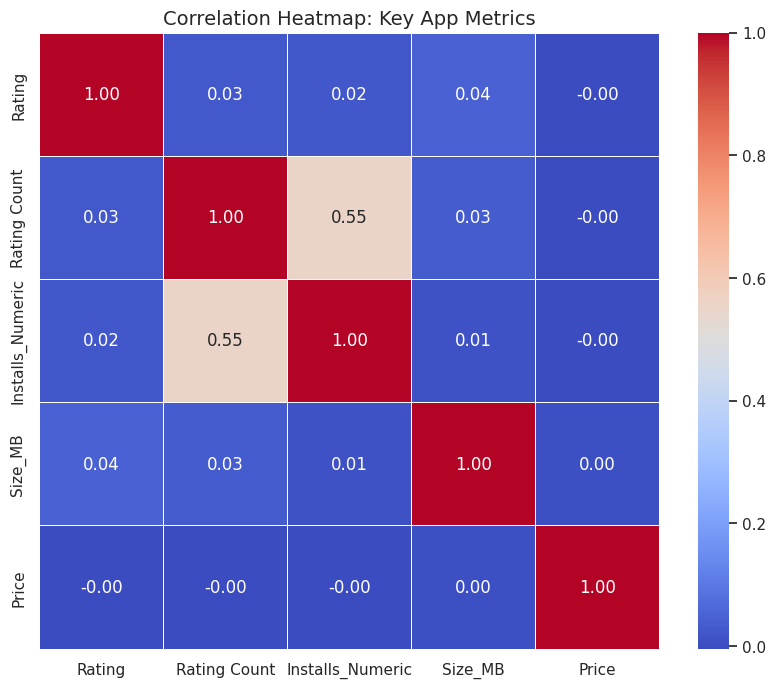

In [6]:
plt.figure(figsize=(10, 8))

cols_to_correlate = ['Rating', 'Rating Count', 'Installs_Numeric', 'Size_MB', 'Price']
existing_cols = [c for c in cols_to_correlate if c in df.columns]

corr = df[existing_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Key App Metrics', fontsize=14)
plt.show()

## 4.2 Scatter Plot: Rating vs. Reviews

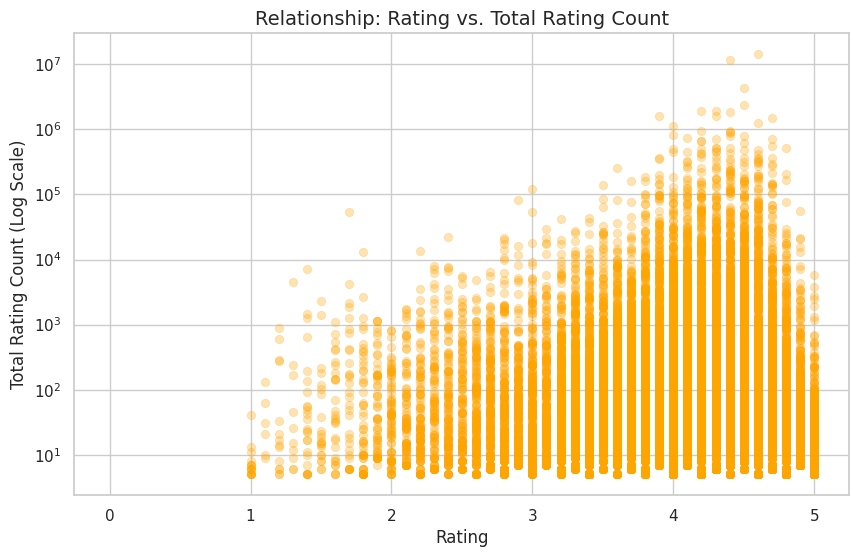

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rating', y='Rating Count', alpha=0.3, color='orange', edgecolor=None)
plt.yscale('log')
plt.title('Relationship: Rating vs. Total Rating Count', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Total Rating Count (Log Scale)')
plt.show()

In [8]:

df.to_csv('analysis_ready_data.csv', index=False)
print("Sheet 3 (EDA) Complete. Data exported for Statistical Analysis.")

Sheet 3 (EDA) Complete. Data exported for Statistical Analysis.
